<a href="https://colab.research.google.com/github/danieligelnik/CCFraudProject/blob/main/DS_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install dependencies as needed:
%pip install kagglehub[pandas-datasets]

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays as hol
from sklearn.model_selection import train_test_split

In [3]:
def load_kagglehub_dataset(dataset_path, file_name):
  # Load the latest version
  return kagglehub.dataset_load(
      KaggleDatasetAdapter.PANDAS,
      dataset_path,
      file_name,
      # Provide any additional arguments like
      # sql_query or pandas_kwargs. See the
      # documenation for more information:
      # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
      )

In [4]:
# Set the path to the file you'd like to load
credit_cards_path_test = "fraudTest.csv"
credit_cards_path_train = "fraudTrain.csv"
main_path="dermisfit/fraud-transactions-dataset"

# Load the latest version
df_cards_train = load_kagglehub_dataset(main_path, credit_cards_path_train)
df_cards_test = load_kagglehub_dataset(main_path, credit_cards_path_test)


100%|██████████| 141M/141M [00:01<00:00, 88.8MB/s]

Extracting zip of fraudTrain.csv...


100%|██████████| 60.5M/60.5M [00:00<00:00, 101MB/s]

Extracting zip of fraudTest.csv...


In [5]:
def df_info(df, what):
  if (what == "head"):
    print("First 5 records:")
    with pd.option_context('display.max_columns', 50):
      display(df.head())
  elif (what == "columns"):
    print("Columns:")
    display(df.columns)
    print(f"Rows / columns: {df.shape}")
  elif (what == "info"):
    print("Missing values:")
    display(df.isna().sum())
    display(df.info())

In [6]:
#merge two data sets into one table
df_cards = pd.concat([df_cards_train, df_cards_test])

# Shuffle the DataFrame to ensure 'is_fraud=1' records are spread equally
df_cards = df_cards.sample(frac=1, random_state=42).reset_index(drop=True)

df_info(df_cards, "head")

First 5 records:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,244469,2020-09-18 07:13:39,5359543825610251,"fraud_Jenkins, Hauck and Friesen",gas_transport,59.91,Michael,Francis,M,1833 Jeanette Stravenue,Belgrade,MT,59714,45.7801,-111.1439,18182,"Engineer, drilling",1975-06-29,784eb609215cbaf3725642a7a9f8bb57,1379488419,45.274075,-111.649432,0
1,434906,2020-12-05 17:48:25,5540636818935089,fraud_Jast-McDermott,shopping_pos,3.96,Kenneth,Foster,M,329 Michael Extension,Lawrence,MA,1843,42.6911,-71.1605,76383,Geoscientist,1985-04-04,74e0ceb1e273a4a37f56dd2b5e6ce03d,1386265705,43.356278,-71.008959,0
2,354659,2019-06-15 11:24:44,2720894374956739,fraud_Bartoletti-Wunsch,gas_transport,51.17,Audrey,Hickman,F,3325 Gregory Square,Mount Clemens,MI,48043,42.5978,-82.8823,16305,"Psychologist, sport and exercise",1927-05-25,93c2b2ce1e96db464d9a7c7f2e9fb1dd,1339759484,42.372483,-83.508020,0
3,197113,2020-08-29 22:50:25,6011438889172900,"fraud_Roob, Conn and Tremblay",shopping_pos,2.06,Allison,Allen,F,40624 Rebecca Spurs,De Witt,AR,72042,34.2853,-91.3336,5161,Electrical engineer,1993-04-08,a269c6b9d9a1603bee720d3ad4fdcfa8,1377816625,33.833389,-91.158293,0
4,468148,2019-07-25 15:50:35,60495593109,"fraud_Kilback, Nitzsche and Leffler",travel,6.58,Randall,Dillon,M,4440 George Mills Suite 591,Dallas,TX,75210,32.7699,-96.7430,1263321,Television camera operator,1942-11-24,9ce4d94b27e36cc2c79bb02351831722,1343231435,32.458643,-96.577001,0


In [7]:
df_info(df_cards, "columns")

Columns:


Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

Rows / columns: (1852394, 23)


In [8]:
df_info(df_cards,"info")

Missing values:


,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   trans_date_trans_time  object 
 2   cc_num                 int64  
 3   merchant               object 
 4   category               object 
 5   amt                    float64
 6   first                  object 
 7   last                   object 
 8   gender                 object 
 9   street                 object 
 10  city                   object 
 11  state                  object 
 12  zip                    int64  
 13  lat                    float64
 14  long                   float64
 15  city_pop               int64  
 16  job                    object 
 17  dob                    object 
 18  trans_num              object 
 19  unix_time              int64  
 20  merch_lat              float64
 21  merch_long             float64
 22  is_fraud          

None

In [9]:
# EDA process
# 1. New column created from local time to indicate weekend or not weekend
# 2. New column of time of a day derived from trans_date_trans_time
# 3. To delete column of transaction hash
# 4. count plot amount against is_fraud
# 5. Encoding on genter(F: 1, M: 0)
# 6. Encoding type of merchant - category
# 7. Statistics.


,count
is_fraud,
0,1842743
1,9651


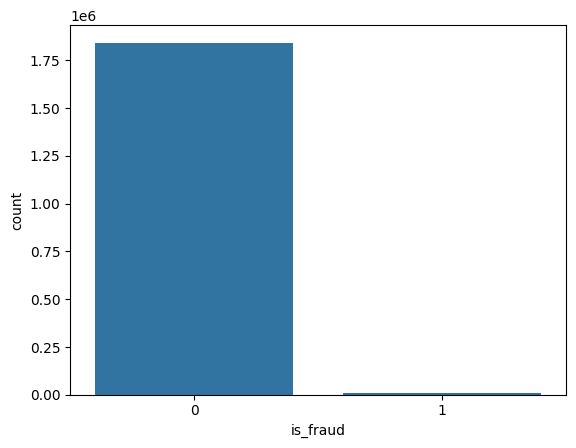

In [10]:
#plots
sns.countplot(x='is_fraud', data=df_cards)
#how many records of fraud in the data set
df_cards['is_fraud'].value_counts()



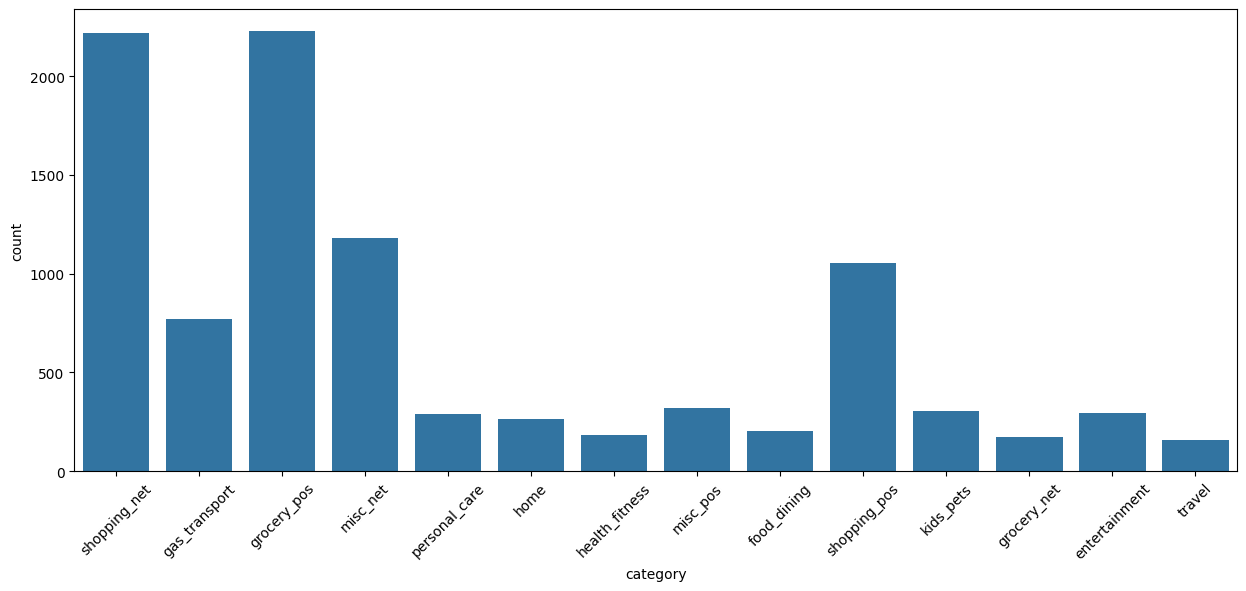

In [11]:
#count plots
plt.figure(figsize=(15, 6))
sns.countplot(x='category', data=df_cards[df_cards['is_fraud'] == 1])
plt.xticks(rotation=45)
plt.show()


<Axes: xlabel='is_fraud', ylabel='amt'>

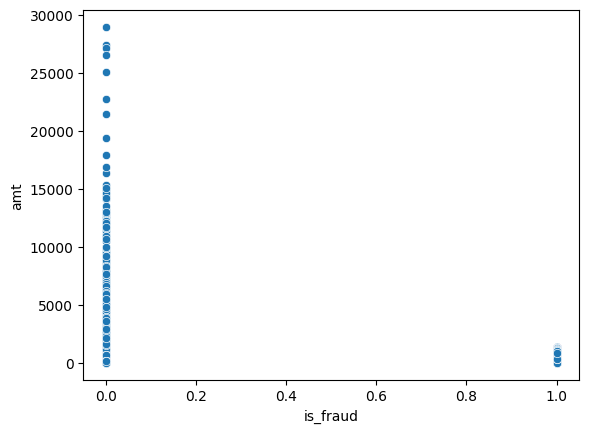

In [12]:
sns.scatterplot(x='is_fraud', y='amt', data=df_cards)



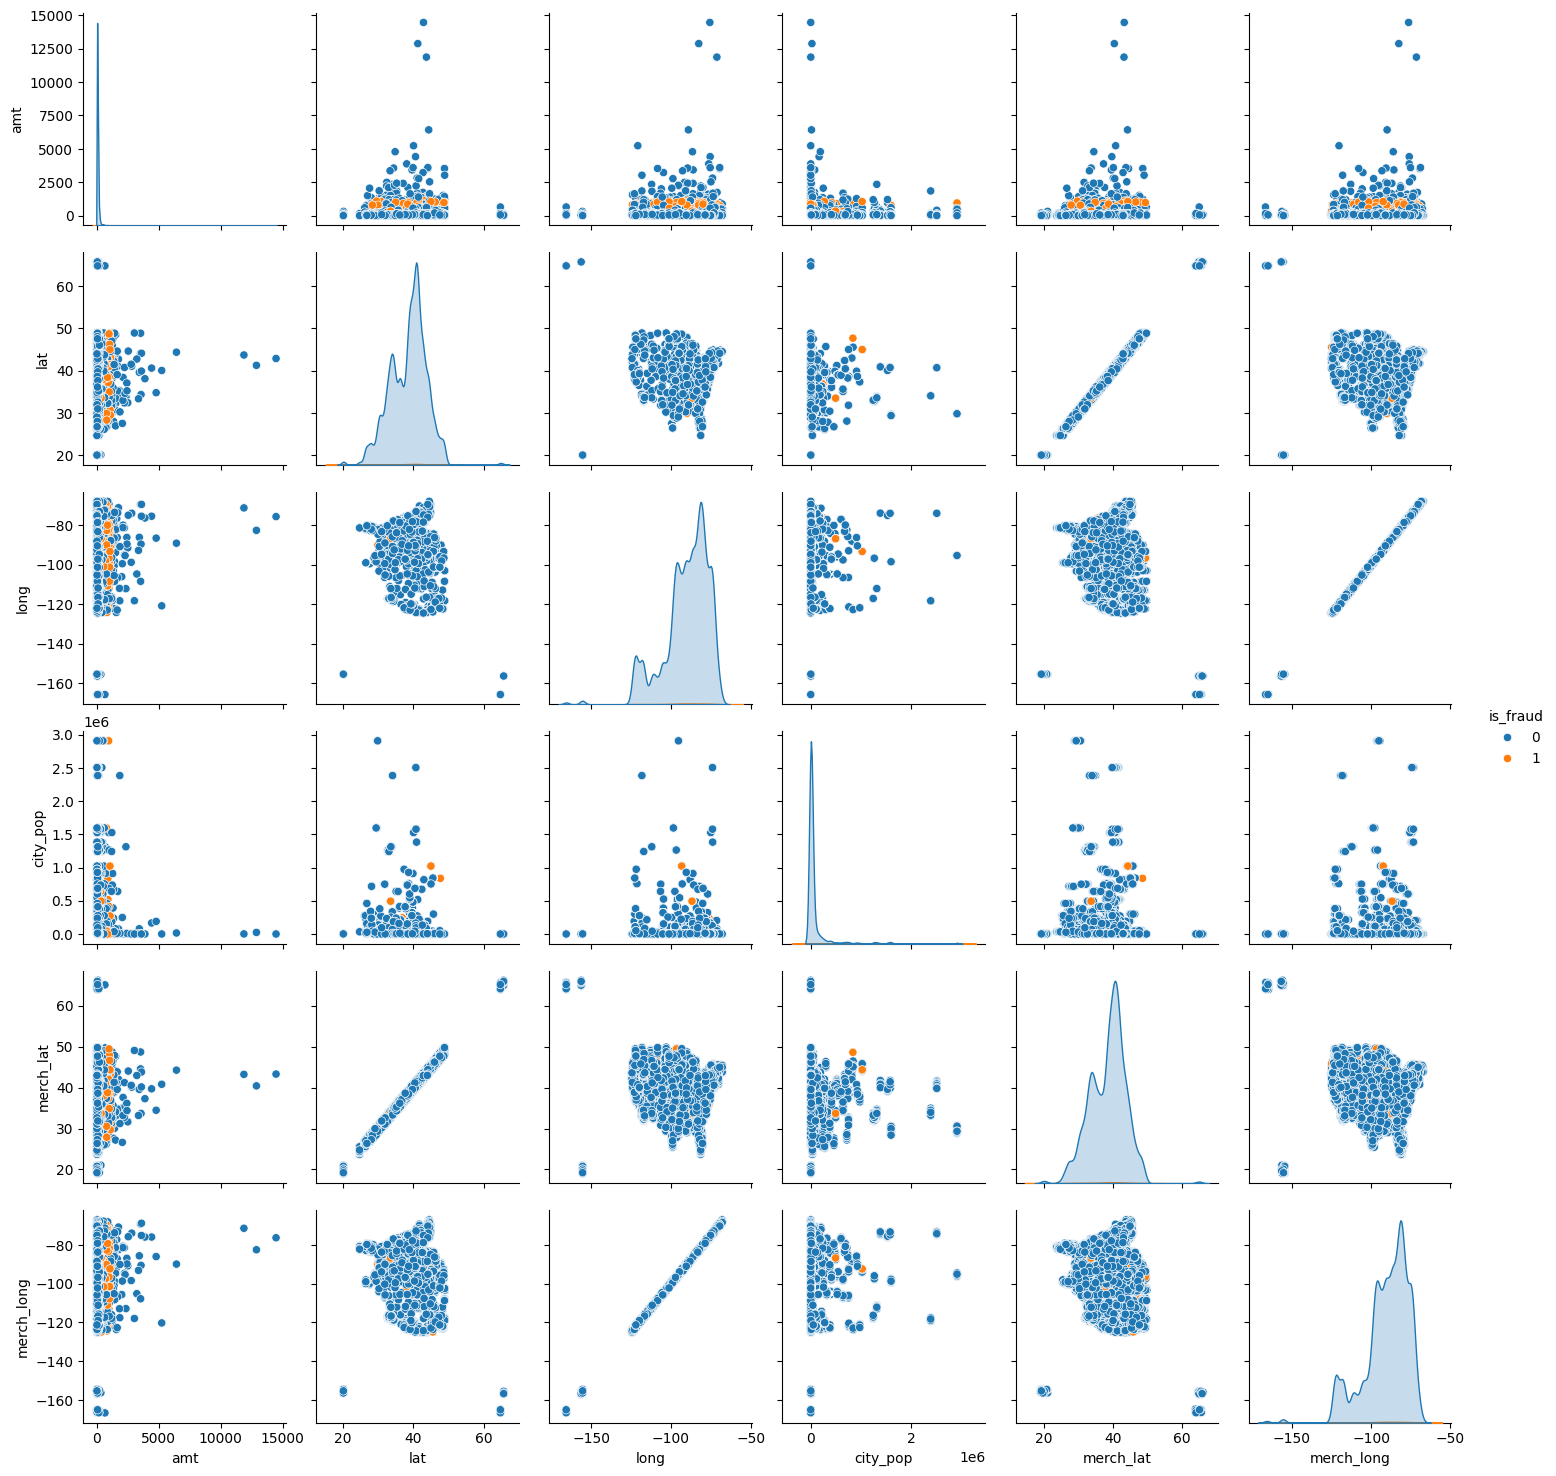

In [13]:
#pair plots
columns_for_pairplot = ['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'is_fraud']
df_sampled = df_cards[columns_for_pairplot].sample(n=50000, random_state=42)
sns.pairplot(df_sampled, hue='is_fraud', diag_kind='kde')

In [14]:
# Convert 'trans_date_trans_time' to datetime format
df_cards_bak = df_cards.copy()
df_cards['trans_date_trans_time'] = pd.to_datetime(df_cards['trans_date_trans_time'])

# Extract day of the week (Monday=0, Sunday=6)
df_cards['day_of_week_raw'] = df_cards['trans_date_trans_time'].dt.dayofweek

# Initialize 'day_a_week' with 1-7 (Monday=1, Sunday=7)
df_cards['day_a_week'] = df_cards['day_of_week_raw'] + 1

# Get the range of years present in the dataset
min_year = df_cards['trans_date_trans_time'].dt.year.min()
max_year = df_cards['trans_date_trans_time'].dt.year.max()

# Load US national holidays for the relevant years
us_holidays = hol.US(years=range(min_year, max_year + 1))

# Create a boolean column to identify national holidays
df_cards['is_national_holiday'] = df_cards['trans_date_trans_time'].dt.date.isin(us_holidays)

# Reclassify national holidays that fall on a weekday:
# If a day is a national holiday AND it's a weekday (day_a_week is 1-5), set 'day_a_week' to 6.
# Weekends (Saturday=6, Sunday=7) remain as they are.
df_cards.loc[(df_cards['is_national_holiday'] == True) & (df_cards['day_a_week'].isin([1, 2, 3, 4, 5])), 'day_a_week'] = 6

# Drop temporary columns
df_cards = df_cards.drop(columns=['day_of_week_raw'])

# Display the value counts for the new 'day_a_week' column to verify
print(df_cards['day_a_week'].value_counts().sort_index())

df_info(df_cards, "head")

day_a_week
1    336439
2    267926
3    177809
4    200916
5    209153
6    316474
7    343677
Name: count, dtype: int64
First 5 records:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,day_a_week,is_national_holiday
0,244469,2020-09-18 07:13:39,5359543825610251,"fraud_Jenkins, Hauck and Friesen",gas_transport,59.91,Michael,Francis,M,1833 Jeanette Stravenue,Belgrade,MT,59714,45.7801,-111.1439,18182,"Engineer, drilling",1975-06-29,784eb609215cbaf3725642a7a9f8bb57,1379488419,45.274075,-111.649432,0,5,False
1,434906,2020-12-05 17:48:25,5540636818935089,fraud_Jast-McDermott,shopping_pos,3.96,Kenneth,Foster,M,329 Michael Extension,Lawrence,MA,1843,42.6911,-71.1605,76383,Geoscientist,1985-04-04,74e0ceb1e273a4a37f56dd2b5e6ce03d,1386265705,43.356278,-71.008959,0,6,False
2,354659,2019-06-15 11:24:44,2720894374956739,fraud_Bartoletti-Wunsch,gas_transport,51.17,Audrey,Hickman,F,3325 Gregory Square,Mount Clemens,MI,48043,42.5978,-82.8823,16305,"Psychologist, sport and exercise",1927-05-25,93c2b2ce1e96db464d9a7c7f2e9fb1dd,1339759484,42.372483,-83.508020,0,6,False
3,197113,2020-08-29 22:50:25,6011438889172900,"fraud_Roob, Conn and Tremblay",shopping_pos,2.06,Allison,Allen,F,40624 Rebecca Spurs,De Witt,AR,72042,34.2853,-91.3336,5161,Electrical engineer,1993-04-08,a269c6b9d9a1603bee720d3ad4fdcfa8,1377816625,33.833389,-91.158293,0,6,False
4,468148,2019-07-25 15:50:35,60495593109,"fraud_Kilback, Nitzsche and Leffler",travel,6.58,Randall,Dillon,M,4440 George Mills Suite 591,Dallas,TX,75210,32.7699,-96.7430,1263321,Television camera operator,1942-11-24,9ce4d94b27e36cc2c79bb02351831722,1343231435,32.458643,-96.577001,0,4,False


In [15]:
# New column of time of a day derived from trans_date_trans_time
df_cards['time_of_day'] = df_cards['trans_date_trans_time'].dt.hour

df_info(df_cards, "head")

First 5 records:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,day_a_week,is_national_holiday,time_of_day
0,244469,2020-09-18 07:13:39,5359543825610251,"fraud_Jenkins, Hauck and Friesen",gas_transport,59.91,Michael,Francis,M,1833 Jeanette Stravenue,Belgrade,MT,59714,45.7801,-111.1439,18182,"Engineer, drilling",1975-06-29,784eb609215cbaf3725642a7a9f8bb57,1379488419,45.274075,-111.649432,0,5,False,7
1,434906,2020-12-05 17:48:25,5540636818935089,fraud_Jast-McDermott,shopping_pos,3.96,Kenneth,Foster,M,329 Michael Extension,Lawrence,MA,1843,42.6911,-71.1605,76383,Geoscientist,1985-04-04,74e0ceb1e273a4a37f56dd2b5e6ce03d,1386265705,43.356278,-71.008959,0,6,False,17
2,354659,2019-06-15 11:24:44,2720894374956739,fraud_Bartoletti-Wunsch,gas_transport,51.17,Audrey,Hickman,F,3325 Gregory Square,Mount Clemens,MI,48043,42.5978,-82.8823,16305,"Psychologist, sport and exercise",1927-05-25,93c2b2ce1e96db464d9a7c7f2e9fb1dd,1339759484,42.372483,-83.508020,0,6,False,11
3,197113,2020-08-29 22:50:25,6011438889172900,"fraud_Roob, Conn and Tremblay",shopping_pos,2.06,Allison,Allen,F,40624 Rebecca Spurs,De Witt,AR,72042,34.2853,-91.3336,5161,Electrical engineer,1993-04-08,a269c6b9d9a1603bee720d3ad4fdcfa8,1377816625,33.833389,-91.158293,0,6,False,22
4,468148,2019-07-25 15:50:35,60495593109,"fraud_Kilback, Nitzsche and Leffler",travel,6.58,Randall,Dillon,M,4440 George Mills Suite 591,Dallas,TX,75210,32.7699,-96.7430,1263321,Television camera operator,1942-11-24,9ce4d94b27e36cc2c79bb02351831722,1343231435,32.458643,-96.577001,0,4,False,15


In [16]:
df_cards = df_cards.drop(columns=['trans_num'])

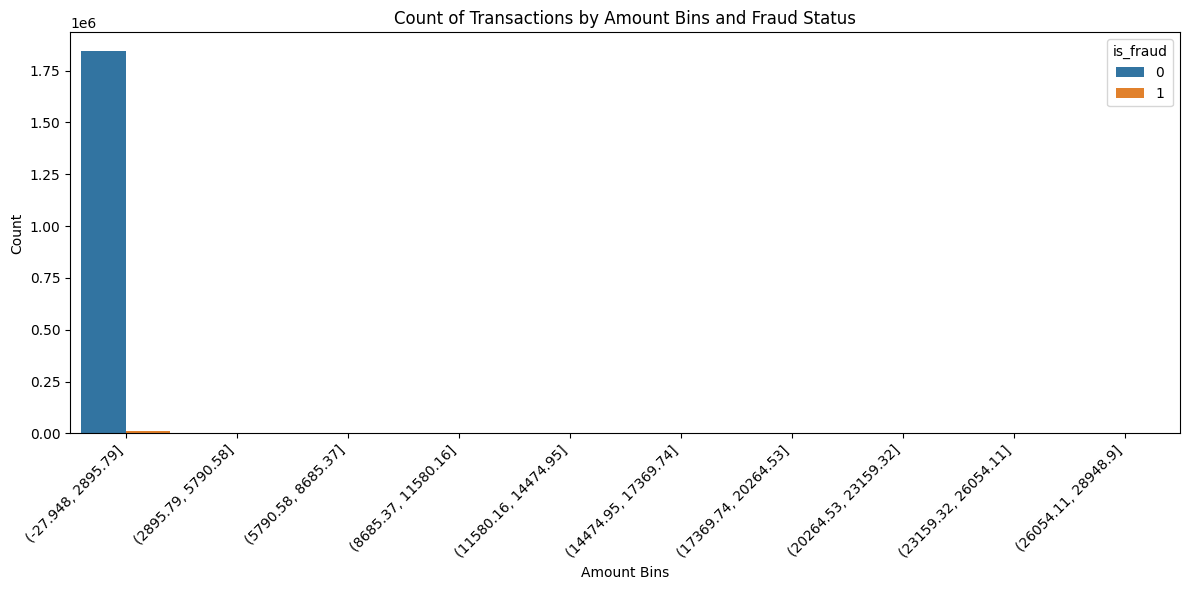

In [17]:
# Create bins for the 'amt' column to use in a count plot
df_cards['amt_bins'] = pd.cut(df_cards['amt'], bins=10)

# Build a count plot of 'amt_bins' against 'is_fraud'
plt.figure(figsize=(12, 6))
sns.countplot(x='amt_bins', hue='is_fraud', data=df_cards)
plt.title('Count of Transactions by Amount Bins and Fraud Status')
plt.xlabel('Amount Bins')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Drop the temporary 'amt_bins' column
df_cards = df_cards.drop(columns=['amt_bins'])

In [61]:
median_no_fraud = df_cards[df_cards['is_fraud'] == 0]['amt'].median()
median_fraud = df_cards[df_cards['is_fraud'] == 1]['amt'].median()
std_no_fraud = df_cards[df_cards['is_fraud'] == 0]['amt'].std()
std_fraud = df_cards[df_cards['is_fraud'] == 1]['amt'].std()

print(f"Median amount for non-fraudulent transactions: ${median_no_fraud:.2f}")
print(f"Median amount for fraudulent transactions: ${median_fraud:.2f}")
print(f"Std for fraudulent transactions: ${std_fraud:.2f}")
print(f"Std for non-fraudulent transactions: ${std_no_fraud:.2f}")

Median amount for non-fraudulent transactions: $47.24
Median amount for fraudulent transactions: $390.00
Std for fraudulent transactions: $391.03
Std for non-fraudulent transactions: $153.55


<Figure size 1200x600 with 0 Axes>

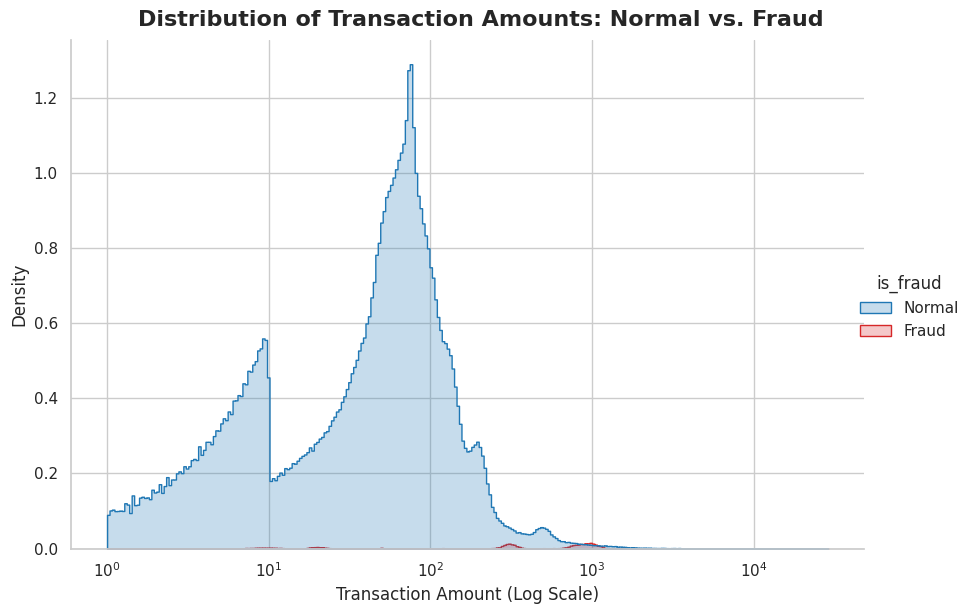

In [19]:
# 1. דגימת הנתונים (קריטי בגלל גודל המאגר)
# כדי שהגרף ייווצר מהר ולא יתקע את המחשב, ניקח מדגם אקראי.
# חשוב להשתמש ב-stratify כדי לשמור על היחס המקורי של ההונאות במדגם.

#df_sampled, _ = train_test_split(df_cards, train_size=100000, stratify=df_cards['is_fraud'], random_state=42)
# 2. הגדרת עיצוב בסיסי לגרף
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
# 3. יצירת ההיסטוגרמה (Displot)
# 'amt' -> המשתנה בציר X (סכום)
# hue='is_fraud' -> צביעה נפרדת לפי סוג העסקה
# element="step" -> יוצר קווי מתאר חלקים וברורים יותר
# stat="density" -> מנרמל כל קבוצה בנפרד (כדי שנוכל להשוות את צורת ההתפלגות)
# log_scale=(True, False) -> מפעיל סולם לוגריתמי רק על ציר X (כדי לראות סכומי ענק)
g = sns.displot(data=df_cards, x='amt', hue='is_fraud', kind="hist",
                element="step", stat="density", log_scale=(True, False),
                palette=['#1f77b4', '#d62728'], height=6, aspect=1.5)
# 4. כותרות מוסברות היטב
g.set_axis_labels("Transaction Amount (Log Scale)", "Density")
g.fig.suptitle('Distribution of Transaction Amounts: Normal vs. Fraud', fontsize=16, fontweight='bold', y=1.02)
# 5. עדכון המקרא (Legend) שיהיה ברור
new_labels = ['Normal', 'Fraud']
for t, l in zip(g._legend.texts, new_labels): t.set_text(l)
plt.show()

In [20]:
# Encoding gender (F: 1, M: 0)
df_cards['gender'] = df_cards['gender'].map({'F': 1, 'M': 0})

df_info(df_cards, "head")

First 5 records:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud,day_a_week,is_national_holiday,time_of_day
0,244469,2020-09-18 07:13:39,5359543825610251,"fraud_Jenkins, Hauck and Friesen",gas_transport,59.91,Michael,Francis,0,1833 Jeanette Stravenue,Belgrade,MT,59714,45.7801,-111.1439,18182,"Engineer, drilling",1975-06-29,1379488419,45.274075,-111.649432,0,5,False,7
1,434906,2020-12-05 17:48:25,5540636818935089,fraud_Jast-McDermott,shopping_pos,3.96,Kenneth,Foster,0,329 Michael Extension,Lawrence,MA,1843,42.6911,-71.1605,76383,Geoscientist,1985-04-04,1386265705,43.356278,-71.008959,0,6,False,17
2,354659,2019-06-15 11:24:44,2720894374956739,fraud_Bartoletti-Wunsch,gas_transport,51.17,Audrey,Hickman,1,3325 Gregory Square,Mount Clemens,MI,48043,42.5978,-82.8823,16305,"Psychologist, sport and exercise",1927-05-25,1339759484,42.372483,-83.508020,0,6,False,11
3,197113,2020-08-29 22:50:25,6011438889172900,"fraud_Roob, Conn and Tremblay",shopping_pos,2.06,Allison,Allen,1,40624 Rebecca Spurs,De Witt,AR,72042,34.2853,-91.3336,5161,Electrical engineer,1993-04-08,1377816625,33.833389,-91.158293,0,6,False,22
4,468148,2019-07-25 15:50:35,60495593109,"fraud_Kilback, Nitzsche and Leffler",travel,6.58,Randall,Dillon,0,4440 George Mills Suite 591,Dallas,TX,75210,32.7699,-96.7430,1263321,Television camera operator,1942-11-24,1343231435,32.458643,-96.577001,0,4,False,15


In [21]:
# Encoding 'category' using one-hot encoding
df_cards = pd.get_dummies(df_cards, columns=['category'], prefix='category')

df_info(df_cards, "head")

First 5 records:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud,day_a_week,is_national_holiday,time_of_day,category_entertainment,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,244469,2020-09-18 07:13:39,5359543825610251,"fraud_Jenkins, Hauck and Friesen",59.91,Michael,Francis,0,1833 Jeanette Stravenue,Belgrade,MT,59714,45.7801,-111.1439,18182,"Engineer, drilling",1975-06-29,1379488419,45.274075,-111.649432,0,5,False,7,False,False,True,False,False,False,False,False,False,False,False,False,False,False
1,434906,2020-12-05 17:48:25,5540636818935089,fraud_Jast-McDermott,3.96,Kenneth,Foster,0,329 Michael Extension,Lawrence,MA,1843,42.6911,-71.1605,76383,Geoscientist,1985-04-04,1386265705,43.356278,-71.008959,0,6,False,17,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,354659,2019-06-15 11:24:44,2720894374956739,fraud_Bartoletti-Wunsch,51.17,Audrey,Hickman,1,3325 Gregory Square,Mount Clemens,MI,48043,42.5978,-82.8823,16305,"Psychologist, sport and exercise",1927-05-25,1339759484,42.372483,-83.508020,0,6,False,11,False,False,True,False,False,False,False,False,False,False,False,False,False,False
3,197113,2020-08-29 22:50:25,6011438889172900,"fraud_Roob, Conn and Tremblay",2.06,Allison,Allen,1,40624 Rebecca Spurs,De Witt,AR,72042,34.2853,-91.3336,5161,Electrical engineer,1993-04-08,1377816625,33.833389,-91.158293,0,6,False,22,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,468148,2019-07-25 15:50:35,60495593109,"fraud_Kilback, Nitzsche and Leffler",6.58,Randall,Dillon,0,4440 George Mills Suite 591,Dallas,TX,75210,32.7699,-96.7430,1263321,Television camera operator,1942-11-24,1343231435,32.458643,-96.577001,0,4,False,15,False,False,False,False,False,False,False,False,False,False,False,False,False,True


In [22]:
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers

    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad

    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = R * c

    return distance

df_cards['distance'] = df_cards.apply(
    lambda row: haversine_distance(row['lat'], row['long'], row['merch_lat'], row['merch_long']),
    axis=1
)

df_info(df_cards, "head")

First 5 records:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud,day_a_week,is_national_holiday,time_of_day,category_entertainment,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,distance
0,244469,2020-09-18 07:13:39,5359543825610251,"fraud_Jenkins, Hauck and Friesen",59.91,Michael,Francis,0,1833 Jeanette Stravenue,Belgrade,MT,59714,45.7801,-111.1439,18182,"Engineer, drilling",1975-06-29,1379488419,45.274075,-111.649432,0,5,False,7,False,False,True,False,False,False,False,False,False,False,False,False,False,False,68.679224
1,434906,2020-12-05 17:48:25,5540636818935089,fraud_Jast-McDermott,3.96,Kenneth,Foster,0,329 Michael Extension,Lawrence,MA,1843,42.6911,-71.1605,76383,Geoscientist,1985-04-04,1386265705,43.356278,-71.008959,0,6,False,17,False,False,False,False,False,False,False,False,False,False,False,False,True,False,74.983242
2,354659,2019-06-15 11:24:44,2720894374956739,fraud_Bartoletti-Wunsch,51.17,Audrey,Hickman,1,3325 Gregory Square,Mount Clemens,MI,48043,42.5978,-82.8823,16305,"Psychologist, sport and exercise",1927-05-25,1339759484,42.372483,-83.508020,0,6,False,11,False,False,True,False,False,False,False,False,False,False,False,False,False,False,57.099604
3,197113,2020-08-29 22:50:25,6011438889172900,"fraud_Roob, Conn and Tremblay",2.06,Allison,Allen,1,40624 Rebecca Spurs,De Witt,AR,72042,34.2853,-91.3336,5161,Electrical engineer,1993-04-08,1377816625,33.833389,-91.158293,0,6,False,22,False,False,False,False,False,False,False,False,False,False,False,False,True,False,52.781450
4,468148,2019-07-25 15:50:35,60495593109,"fraud_Kilback, Nitzsche and Leffler",6.58,Randall,Dillon,0,4440 George Mills Suite 591,Dallas,TX,75210,32.7699,-96.7430,1263321,Television camera operator,1942-11-24,1343231435,32.458643,-96.577001,0,4,False,15,False,False,False,False,False,False,False,False,False,False,False,False,False,True,37.942009


In [23]:
average_distance_fraud = df_cards[df_cards['is_fraud'] == 1]['distance'].mean()
print(f"Average distance for fraudulent transactions: {average_distance_fraud:.2f} km")
average_distance_no_fraud = df_cards[df_cards['is_fraud'] == 0]['distance'].mean()
print(f"Average distance for non fraudulent transactions: {average_distance_no_fraud:.2f} km")

Average distance for fraudulent transactions: 76.26 km
Average distance for non fraudulent transactions: 76.11 km


In [24]:
average_distances = df_cards.groupby('is_fraud')['distance'].mean()
print("Average distance for Normal transactions (0): {:.2f} km".format(average_distances[0]))
print("Average distance for Fraud transactions (1): {:.2f} km".format(average_distances[1]))


Average distance for Normal transactions (0): 76.11 km
Average distance for Fraud transactions (1): 76.26 km


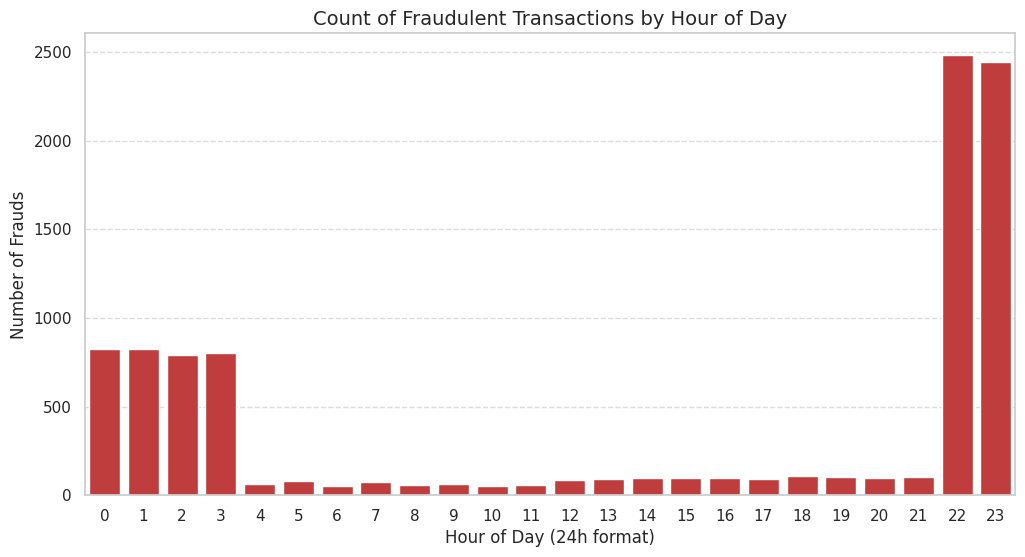

In [25]:
plt.figure(figsize=(12, 6))
# Filter for fraud transactions and plot the count per hour
sns.countplot(x='time_of_day', data=df_cards[df_cards['is_fraud'] == 1], color='#d62728')
plt.title('Count of Fraudulent Transactions by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day (24h format)')
plt.ylabel('Number of Frauds')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

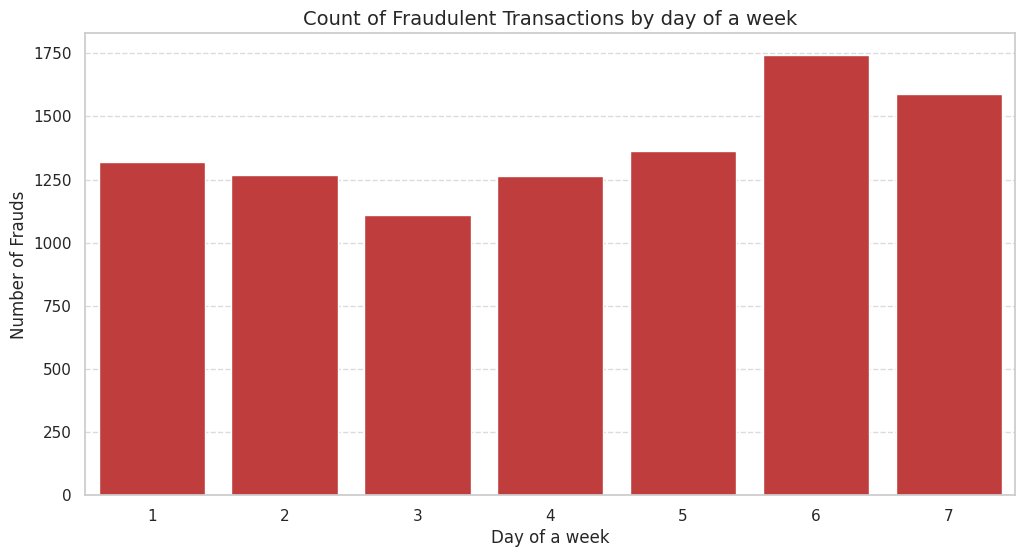

In [26]:
plt.figure(figsize=(12, 6))
# Filter for fraud transactions and plot the count per hour
sns.countplot(x='day_a_week', data=df_cards[df_cards['is_fraud'] == 1], color='#d62728')
plt.title('Count of Fraudulent Transactions by day of a week', fontsize=14)
plt.xlabel('Day of a week')
plt.ylabel('Number of Frauds')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

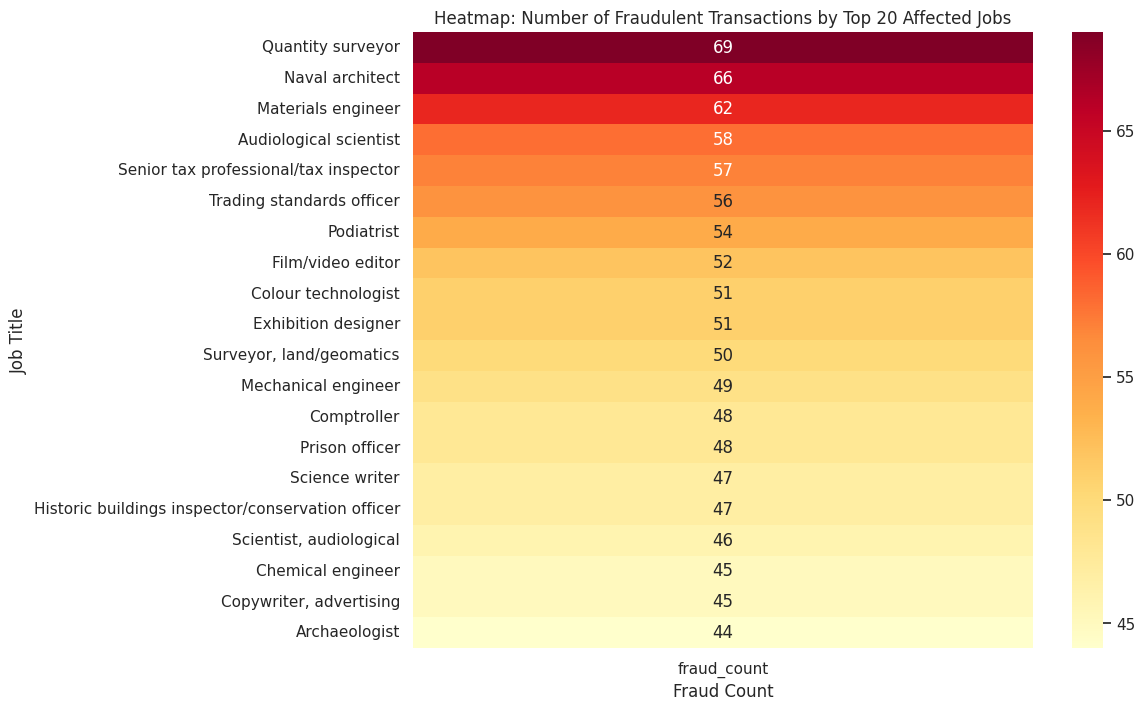

In [27]:
# Identify the top 20 jobs with the most fraud transactions for better visibility
top_fraud_jobs = df_cards[df_cards['is_fraud'] == 1]['job'].value_counts().head(20).index

# Filter the dataframe for these jobs
df_top_jobs = df_cards[df_cards['job'].isin(top_fraud_jobs)]

# Create a pivot table counting frauds per job
# We'll use a simple count of fraud cases
job_fraud_counts = df_top_jobs[df_top_jobs['is_fraud'] == 1].groupby('job').size().to_frame('fraud_count')

plt.figure(figsize=(10, 8))
sns.heatmap(job_fraud_counts.sort_values(by='fraud_count', ascending=False), annot=True, fmt='d', cmap='YlOrRd')
plt.title('Heatmap: Number of Fraudulent Transactions by Top 20 Affected Jobs')
plt.ylabel('Job Title')
plt.xlabel('Fraud Count')
plt.show()

In [28]:
def get_cc_vendor(cc_num):
    cc_str = str(cc_num)
    if cc_str.startswith('4'):
        return 'Visa'
    elif cc_str.startswith(('51', '52', '53', '54', '55')) or (2221 <= int(cc_str[:4]) <= 2720):
        return 'Mastercard'
    elif cc_str.startswith(('34', '37')):
        return 'Amex'
    elif cc_str.startswith('6011') or cc_str.startswith('65'):
        return 'Discover'
    elif cc_str.startswith(('300', '301', '302', '303', '304', '305', '36', '38')):
        return 'Diners'
    elif cc_str.startswith(('3528', '3589')):
        return 'JCB'
    else:
        return 'Other'

df_cards['cc_vendor'] = df_cards['cc_num'].apply(get_cc_vendor)

print("Credit Card Vendor Distribution:")
display(df_cards['cc_vendor'].value_counts())

df_info(df_cards, 'head')

Credit Card Vendor Distribution:


,count
cc_vendor,
Other,598676
Visa,598643
Diners,179974
Amex,177089
Discover,150084
Mastercard,137678
JCB,10250


First 5 records:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud,day_a_week,is_national_holiday,time_of_day,category_entertainment,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,distance,cc_vendor
0,244469,2020-09-18 07:13:39,5359543825610251,"fraud_Jenkins, Hauck and Friesen",59.91,Michael,Francis,0,1833 Jeanette Stravenue,Belgrade,MT,59714,45.7801,-111.1439,18182,"Engineer, drilling",1975-06-29,1379488419,45.274075,-111.649432,0,5,False,7,False,False,True,False,False,False,False,False,False,False,False,False,False,False,68.679224,Mastercard
1,434906,2020-12-05 17:48:25,5540636818935089,fraud_Jast-McDermott,3.96,Kenneth,Foster,0,329 Michael Extension,Lawrence,MA,1843,42.6911,-71.1605,76383,Geoscientist,1985-04-04,1386265705,43.356278,-71.008959,0,6,False,17,False,False,False,False,False,False,False,False,False,False,False,False,True,False,74.983242,Mastercard
2,354659,2019-06-15 11:24:44,2720894374956739,fraud_Bartoletti-Wunsch,51.17,Audrey,Hickman,1,3325 Gregory Square,Mount Clemens,MI,48043,42.5978,-82.8823,16305,"Psychologist, sport and exercise",1927-05-25,1339759484,42.372483,-83.508020,0,6,False,11,False,False,True,False,False,False,False,False,False,False,False,False,False,False,57.099604,Mastercard
3,197113,2020-08-29 22:50:25,6011438889172900,"fraud_Roob, Conn and Tremblay",2.06,Allison,Allen,1,40624 Rebecca Spurs,De Witt,AR,72042,34.2853,-91.3336,5161,Electrical engineer,1993-04-08,1377816625,33.833389,-91.158293,0,6,False,22,False,False,False,False,False,False,False,False,False,False,False,False,True,False,52.781450,Discover
4,468148,2019-07-25 15:50:35,60495593109,"fraud_Kilback, Nitzsche and Leffler",6.58,Randall,Dillon,0,4440 George Mills Suite 591,Dallas,TX,75210,32.7699,-96.7430,1263321,Television camera operator,1942-11-24,1343231435,32.458643,-96.577001,0,4,False,15,False,False,False,False,False,False,False,False,False,False,False,False,False,True,37.942009,Other


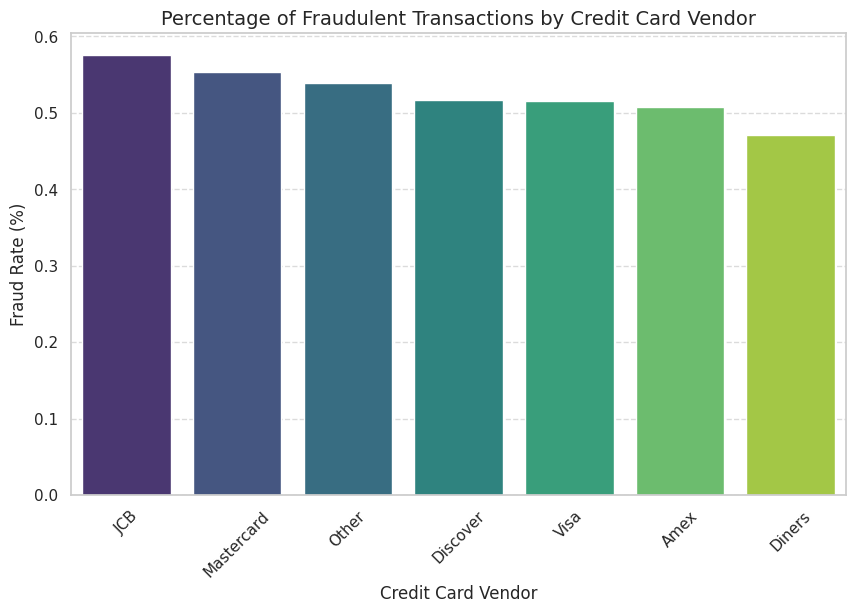

In [29]:
# Calculate the fraud rate (percentage) for each vendor
vendor_stats = df_cards.groupby('cc_vendor')['is_fraud'].agg(['count', 'sum'])
vendor_stats['fraud_rate'] = (vendor_stats['sum'] / vendor_stats['count']) * 100
vendor_stats = vendor_stats.sort_values(by='fraud_rate', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=vendor_stats.index, y=vendor_stats['fraud_rate'], palette='viridis', hue=vendor_stats.index, legend=False)

plt.title('Percentage of Fraudulent Transactions by Credit Card Vendor', fontsize=14)
plt.xlabel('Credit Card Vendor')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_7072/1628789369.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_by_vendor.index, y=fraud_by_vendor.values, palette='viridis')


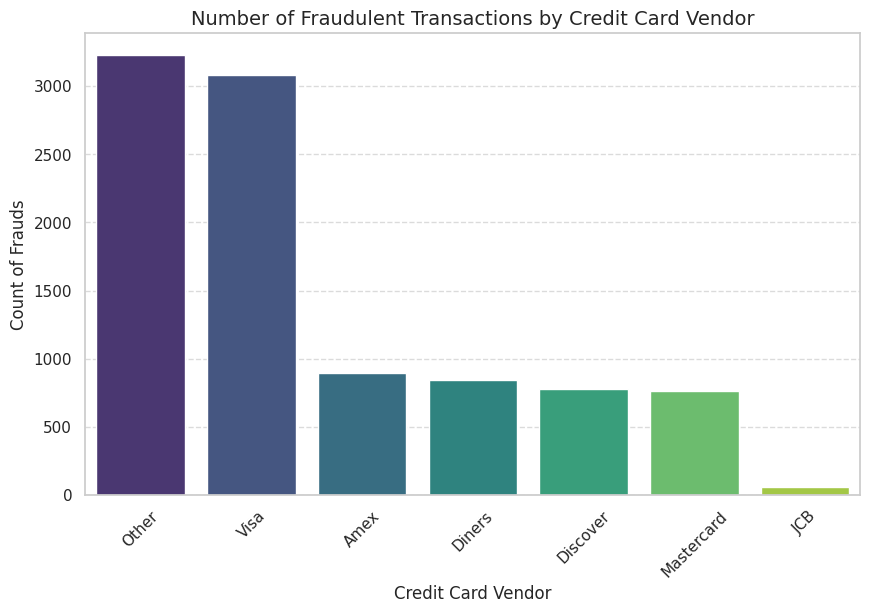

In [30]:
plt.figure(figsize=(10, 6))
# Filter for fraudulent transactions and plot count by vendor
fraud_by_vendor = df_cards[df_cards['is_fraud'] == 1]['cc_vendor'].value_counts()
sns.barplot(x=fraud_by_vendor.index, y=fraud_by_vendor.values, palette='viridis')

plt.title('Number of Fraudulent Transactions by Credit Card Vendor', fontsize=14)
plt.xlabel('Credit Card Vendor')
plt.ylabel('Count of Frauds')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

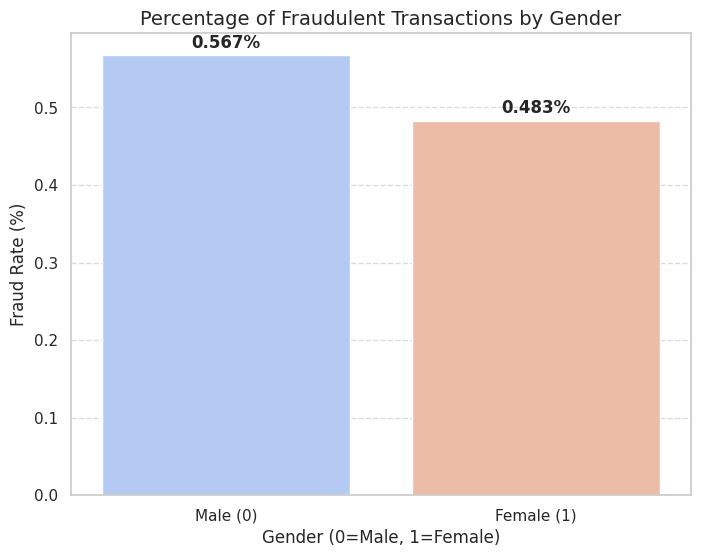

In [31]:
# Calculate fraud rate by gender
gender_fraud_rate = df_cards.groupby('gender')['is_fraud'].mean() * 100

# Map back for labels: 1 is Female, 0 is Male
gender_labels = ['Male (0)', 'Female (1)']

plt.figure(figsize=(8, 6))
sns.barplot(x=gender_fraud_rate.index, y=gender_fraud_rate.values, palette='coolwarm', hue=gender_fraud_rate.index, legend=False)

plt.title('Percentage of Fraudulent Transactions by Gender', fontsize=14)
plt.xlabel('Gender (0=Male, 1=Female)')
plt.ylabel('Fraud Rate (%)')
plt.xticks(ticks=[0, 1], labels=gender_labels)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of bars
for i, val in enumerate(gender_fraud_rate.values):
    plt.text(i, val + 0.01, f"{val:.3f}%", ha='center', fontweight='bold')

plt.show()

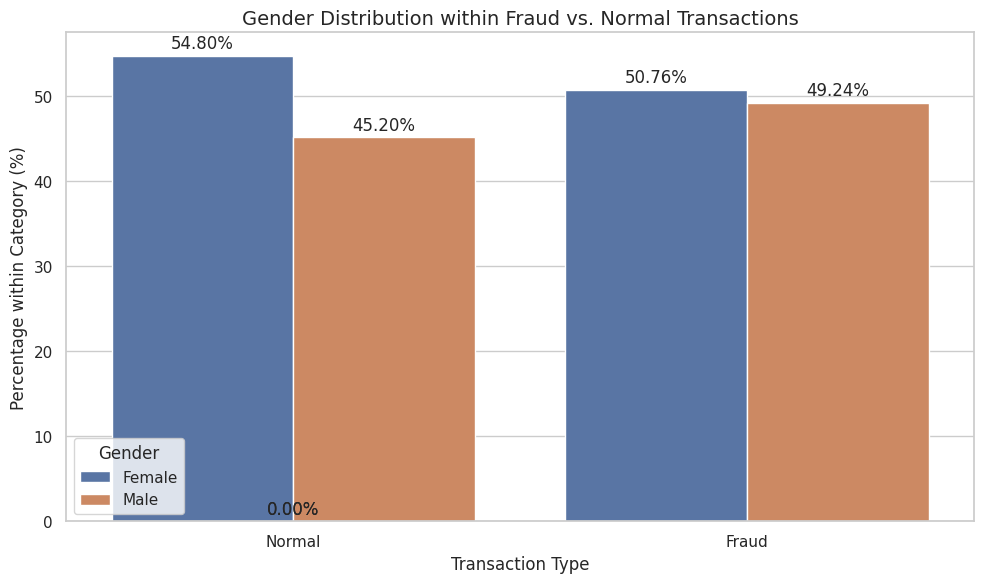

In [32]:
# Calculate the percentage of each gender WITHIN each fraud category
gender_dist = df_cards.groupby('is_fraud')['gender'].value_counts(normalize=True).rename('percentage').reset_index()

# Map gender back to labels
gender_dist['gender_label'] = gender_dist['gender'].map({1: 'Female', 0: 'Male'})
gender_dist['percentage'] *= 100

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='is_fraud', y='percentage', hue='gender_label', data=gender_dist)

plt.title('Gender Distribution within Fraud vs. Normal Transactions', fontsize=14)
plt.xlabel('Transaction Type')
plt.ylabel('Percentage within Category (%)')

# Set descriptive x-axis labels
plt.xticks(ticks=[0, 1], labels=['Normal', 'Fraud'])

plt.legend(title='Gender')

# Add labels on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.tight_layout()
plt.show()

In [49]:
# Identify boolean columns
bool_cols = df_cards.select_dtypes(include=['bool']).columns

# Transform boolean columns to integer (1 for True, 0 for False)
df_cards[bool_cols] = df_cards[bool_cols].astype(int)

print(f"Transformed columns: {list(bool_cols)}")
display(df_cards[bool_cols].head())

Transformed columns: ['is_national_holiday', 'category_entertainment', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel']


,is_national_holiday,category_entertainment,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [54]:
# Convert dob to datetime if it's not already
df_cards['dob'] = pd.to_datetime(df_cards['dob'])

# Calculate age: (Transaction Date - Date of Birth)
# We use the total days divided by 365.25 to account for leap years
df_cards['age'] = (df_cards['trans_date_trans_time'] - df_cards['dob']).dt.days // 365

print("Age column created. Statistical summary of age:")
pd.set_option('display.float_format', lambda x: '%2f' %x)
display(df_cards['age'].describe())
display(df_cards[['dob', 'trans_date_trans_time', 'age']].head())

Age column created. Statistical summary of age:


,age
count,1852394.000000
mean,45.796896
std,17.423925
min,13.000000
25%,32.000000
50%,44.000000
75%,57.000000
max,96.000000


,dob,trans_date_trans_time,age
0,1975-06-29,2020-09-18 07:13:39,45
1,1985-04-04,2020-12-05 17:48:25,35
2,1927-05-25,2019-06-15 11:24:44,92
3,1993-04-08,2020-08-29 22:50:25,27
4,1942-11-24,2019-07-25 15:50:35,76


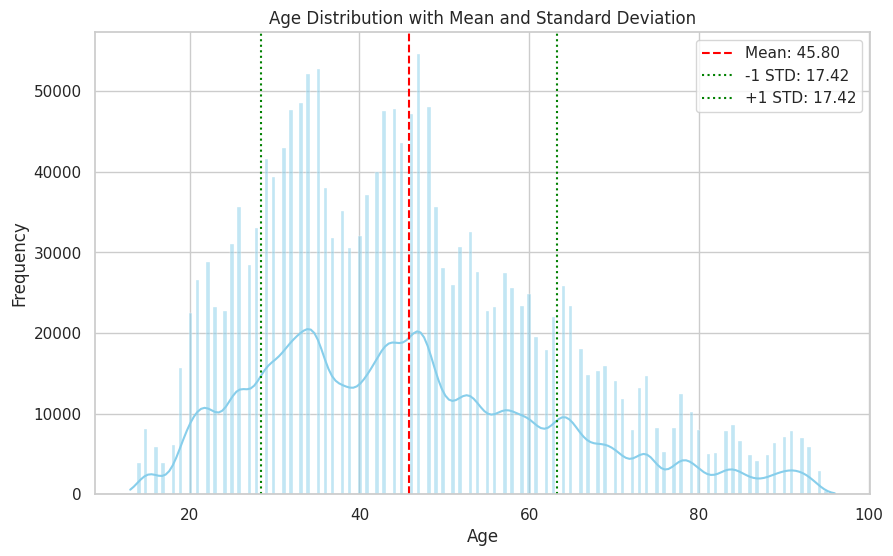

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate statistics
mean_age = df_cards['age'].mean()
std_age = df_cards['age'].std()

plt.figure(figsize=(10, 6))
sns.histplot(df_cards['age'], kde=True, color='skyblue')

# Add lines for mean and standard deviation
plt.axvline(mean_age, color='red', linestyle='--', label=f'Mean: {mean_age:.2f}')
plt.axvline(mean_age - std_age, color='green', linestyle=':', label=f'-1 STD: {std_age:.2f}')
plt.axvline(mean_age + std_age, color='green', linestyle=':', label=f'+1 STD: {std_age:.2f}')

plt.title('Age Distribution with Mean and Standard Deviation')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.show()

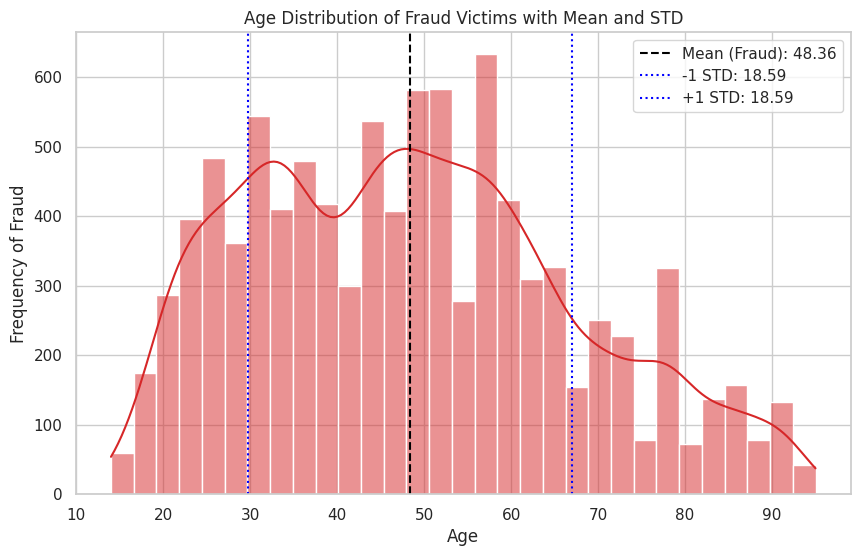

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for fraud cases
df_fraud = df_cards[df_cards['is_fraud'] == 1]

# Calculate statistics for fraud cases
mean_age_fraud = df_fraud['age'].mean()
std_age_fraud = df_fraud['age'].std()

plt.figure(figsize=(10, 6))
sns.histplot(df_fraud['age'], kde=True, color='#d62728')

# Add lines for mean and standard deviation
plt.axvline(mean_age_fraud, color='black', linestyle='--', label=f'Mean (Fraud): {mean_age_fraud:.2f}')
plt.axvline(mean_age_fraud - std_age_fraud, color='blue', linestyle=':', label=f'-1 STD: {std_age_fraud:.2f}')
plt.axvline(mean_age_fraud + std_age_fraud, color='blue', linestyle=':', label=f'+1 STD: {std_age_fraud:.2f}')

plt.title('Age Distribution of Fraud Victims with Mean and STD')
plt.xlabel('Age')
plt.ylabel('Frequency of Fraud')
plt.legend()
plt.show()

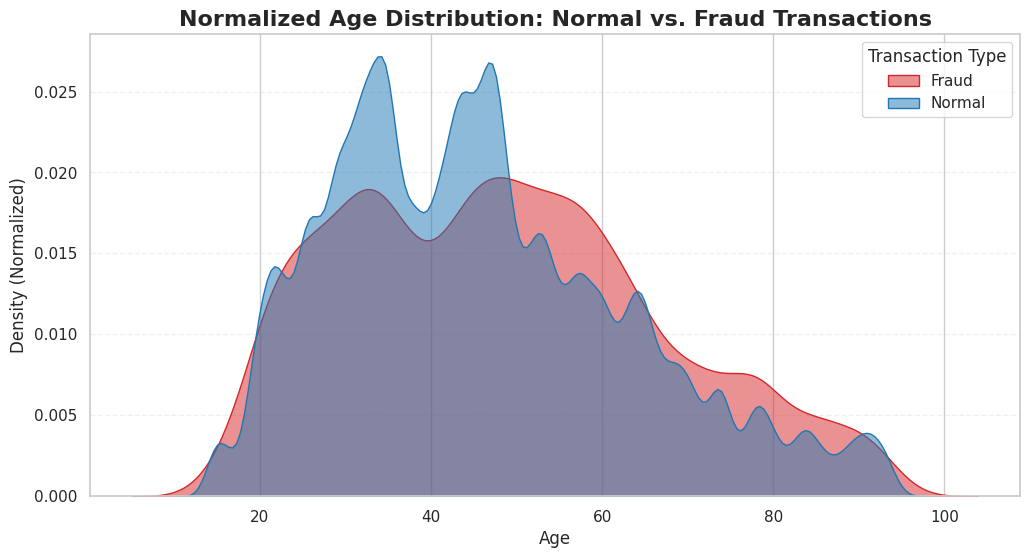

In [66]:
plt.figure(figsize=(12, 6))

# יצירת גרף KDE (התפלגות צפיפות) להשוואת אוכלוסיות
# common_norm=False דואג שכל קבוצה תנורמל בנפרד ל-100%
sns.kdeplot(data=df_cards, x='age', hue='is_fraud', fill=True,
            common_norm=False, palette=['#1f77b4', '#d62728'], alpha=0.5)

plt.title('Normalized Age Distribution: Normal vs. Fraud Transactions', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Density (Normalized)', fontsize=12)
plt.legend(title='Transaction Type', labels=['Fraud', 'Normal'])
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

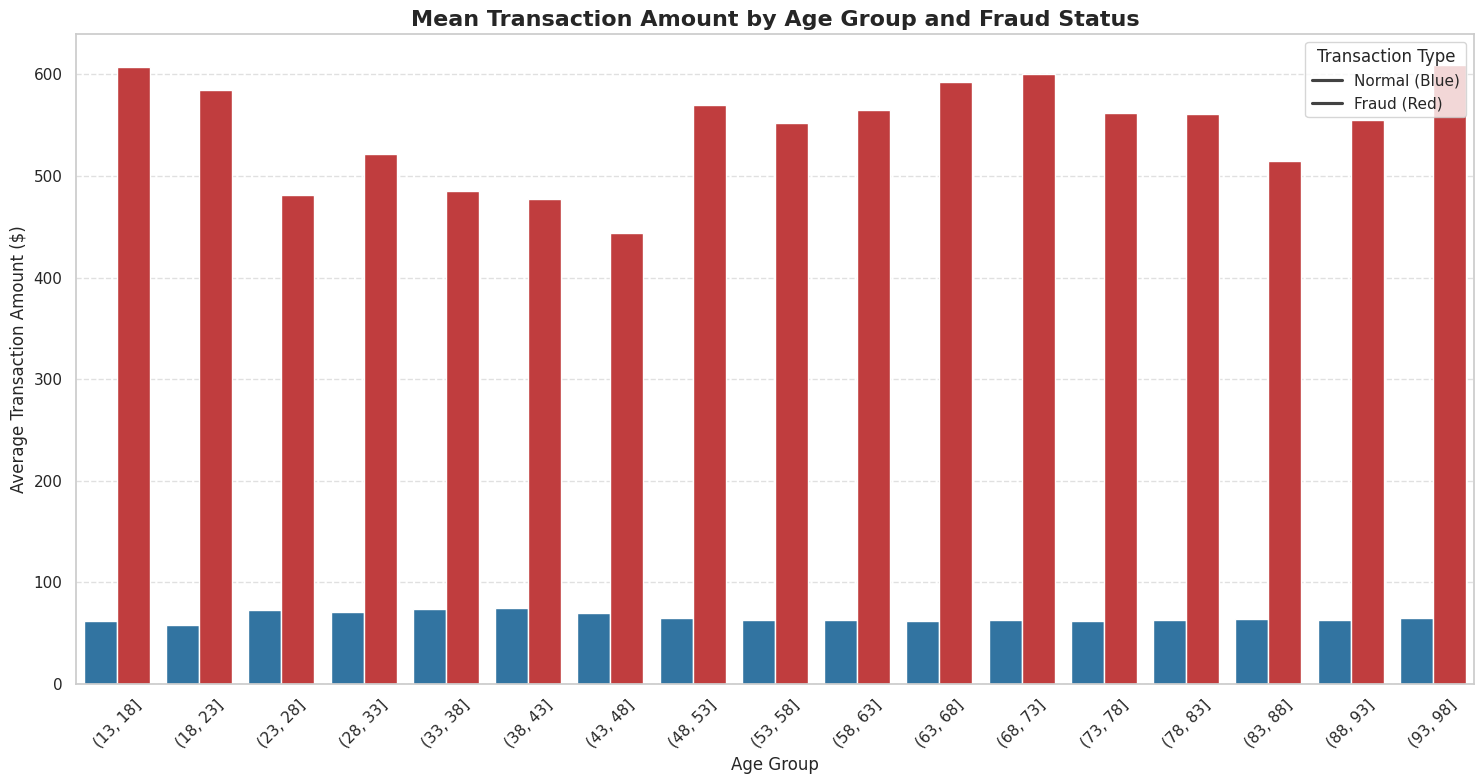

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create age bins (e.g., every 5 years)
bins = list(range(int(df_cards['age'].min()), int(df_cards['age'].max()) + 5, 5))
df_cards['age_group'] = pd.cut(df_cards['age'], bins=bins)

# Calculate mean amount by age group and fraud status
df_age_group_amt = df_cards.groupby(['age_group', 'is_fraud'], observed=False)['amt'].mean().reset_index()

plt.figure(figsize=(15, 8))
sns.barplot(data=df_age_group_amt, x='age_group', y='amt', hue='is_fraud', palette=['#1f77b4', '#d62728'])

plt.title('Mean Transaction Amount by Age Group and Fraud Status', fontsize=16, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Average Transaction Amount ($)', fontsize=12)
plt.legend(title='Transaction Type', labels=['Normal (Blue)', 'Fraud (Red)'])
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Remove temporary column
df_cards.drop(columns=['age_group'], inplace=True)

Correlation of numeric features with is_fraud:


,is_fraud
is_fraud,1.000000
amt,0.209308
category_shopping_net,0.042454
category_grocery_pos,0.033485
category_misc_net,0.024667
time_of_day,0.013196
age,0.010651
category_shopping_pos,0.004948
day_a_week,0.004236
lat,0.002904


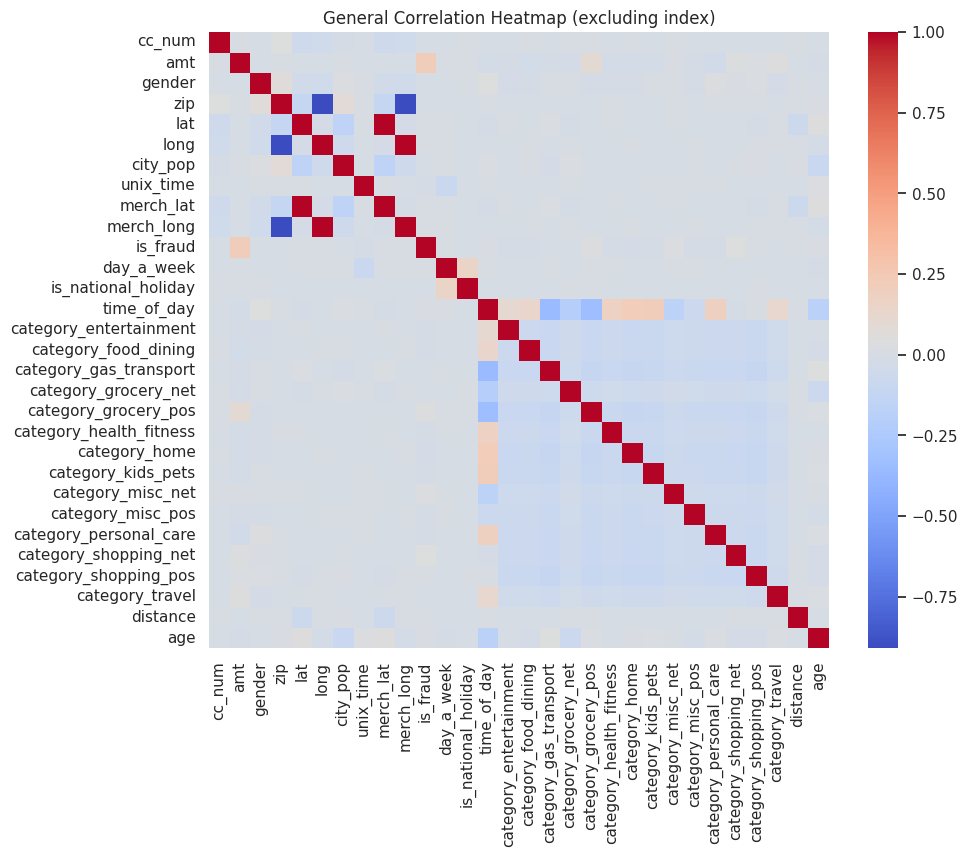

In [62]:
# Select only numeric columns and remove 'Unnamed: 0'

numeric_df = df_cards.select_dtypes(include=['number'])
if 'Unnamed: 0' in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=['Unnamed: 0'])

# Calculate correlation with 'is_fraud' specifically
corr_with_fraud = numeric_df.corr()['is_fraud'].sort_values(ascending=False).to_frame()

print("Correlation of numeric features with is_fraud:")
display(corr_with_fraud)

# Plotting the correlations
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title('General Correlation Heatmap (excluding index)')
plt.show()

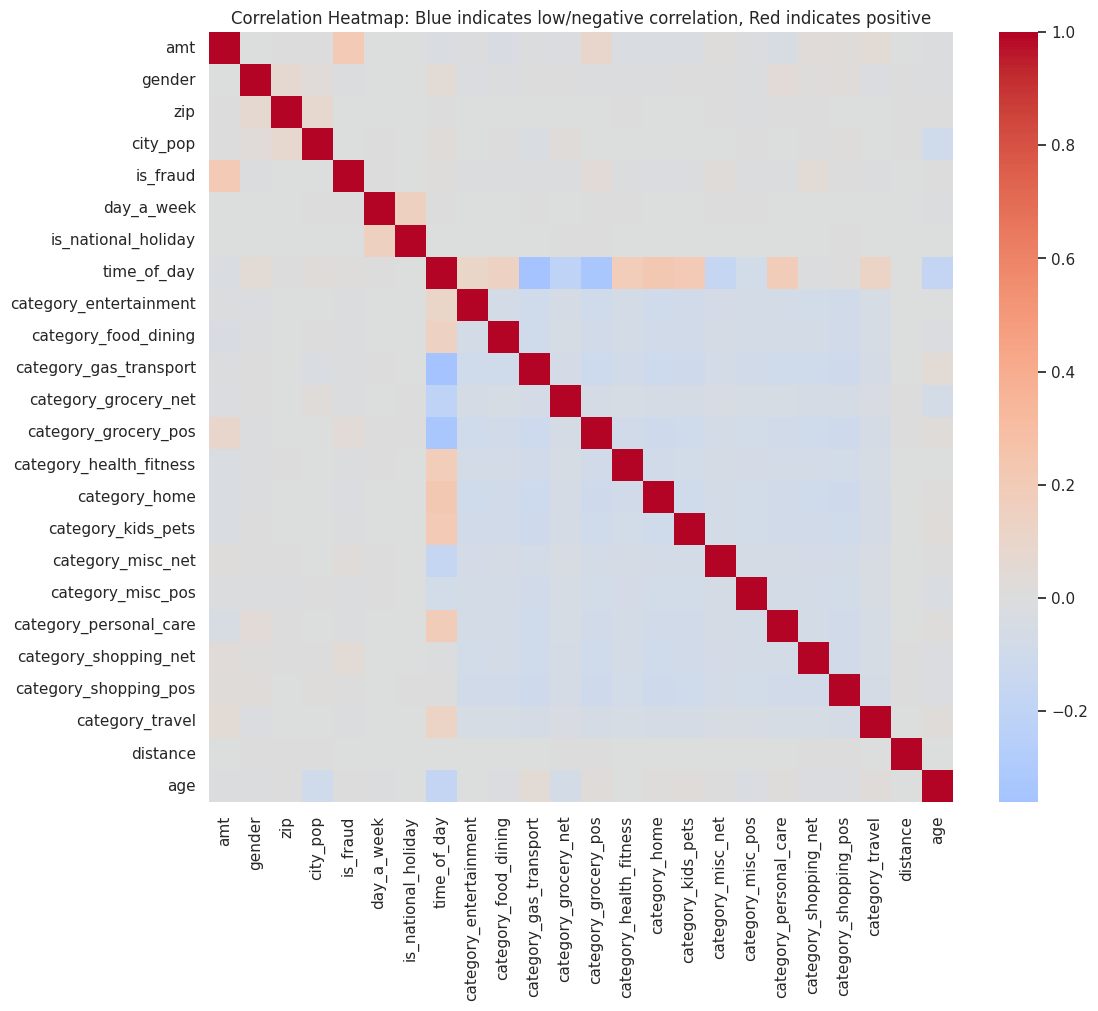

Top correlations with is_fraud:


,is_fraud
is_fraud,1.000000
amt,0.209308
category_shopping_net,0.042454
category_grocery_pos,0.033485
category_misc_net,0.024667
time_of_day,0.013196
age,0.010651
category_shopping_pos,0.004948
day_a_week,0.004236
distance,0.000359


In [65]:
df_cards2 = df_cards.copy()
# Dropping non-predictive or redundant numeric columns for a cleaner heatmap
df_cards2 = df_cards2.drop(columns=['merch_long', 'merch_lat', 'lat', 'long', 'unix_time', 'cc_num'])

numeric_df = df_cards2.select_dtypes(include=['number'])
if 'Unnamed: 0' in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=['Unnamed: 0'])

# Plotting the correlations with annotations to see the actual numbers
plt.figure(figsize=(12, 10))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Blue indicates low/negative correlation, Red indicates positive')
plt.show()

print("Top correlations with is_fraud:")
display(correlation_matrix['is_fraud'].sort_values(ascending=False).to_frame())

Conclusions from all made EDA
1. To remove geo location before training
2. there is no correlation between zip and city population, so it can be removed before training
3. There is strong correlation between sum of the transaction and the fraud
4. There is correlation between fraud and holidays.
5. Because the target is to predict fraud and there strong correlation between fraud and the amount of the transaction, the erasion of the ouliners will cause to loose essential data from the data set and will negatively impact the prediction.
6. From the data analysis above it is clear that there is no linear correlation between various features which suggests to use such prediction models as Forest or Tree to train to predict fraudent.  